In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns 

In [79]:
df_filtered = pd.read_csv("clean_data.csv", encoding_errors="ignore")

Create a new column to represent total sales

In [80]:
df_filtered["TotalSales"] = df_filtered["Quantity"] * df_filtered["UnitPrice"]

In [81]:
df_filtered.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales
0,536370,22728,ALARM CLOCK BAKELIKE PINK,24,2010-12-01 08:45:00,3.75,12583.0,France,90.0
1,536370,22727,ALARM CLOCK BAKELIKE RED,24,2010-12-01 08:45:00,3.75,12583.0,France,90.0
2,536370,22726,ALARM CLOCK BAKELIKE GREEN,12,2010-12-01 08:45:00,3.75,12583.0,France,45.0
3,536370,21724,PANDA AND BUNNIES STICKER SHEET,12,2010-12-01 08:45:00,0.85,12583.0,France,10.2
4,536370,21883,STARS GIFT TAPE,24,2010-12-01 08:45:00,0.65,12583.0,France,15.6


In [82]:
df_filtered.groupby("Description")["TotalSales"].sum().sort_values(ascending=False)

Description
RABBIT NIGHT LIGHT                     28669.76
REGENCY CAKESTAND 3 TIER               24214.20
ROUND SNACK BOXES SET OF4 WOODLAND     18078.35
SPACEBOY LUNCH BOX                     13821.90
ROUND SNACK BOXES SET OF 4 FRUITS      12140.55
                                         ...   
HANGING SPRING FLOWER EGG SMALL            0.65
SET 12 COLOURING PENCILS DOILEY            0.65
MIXED NUTS LIGHT GREEN BOWL                0.42
FUSCHIA VOILE POINTY SHOE DEC              0.39
RETRO PILL BOX KEY CHAIN,THE KING          0.19
Name: TotalSales, Length: 2667, dtype: float64

In [83]:
df_filtered.shape

(35227, 9)

In [84]:
df_filtered.dtypes

InvoiceNo        int64
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
TotalSales     float64
dtype: object

In [85]:
df_filtered["InvoiceDate"] = pd.to_datetime(df_filtered["InvoiceDate"], format="%Y-%m-%d %H:%M:%S")
df_filtered["CustomerID"] = df_filtered["CustomerID"].astype(str)

In [86]:
# revenue by month
df_filtered.groupby(df_filtered["InvoiceDate"].dt.to_period("M"))["TotalSales"].sum()

InvoiceDate
2010-12     60623.16
2011-01    100241.79
2011-02     77868.51
2011-03    100061.31
2011-04     41165.83
2011-05    101873.15
2011-06    110954.22
2011-07     67986.99
2011-08    124847.20
2011-09    109249.12
2011-10    166721.93
2011-11    140244.95
2011-12     36069.70
Freq: M, Name: TotalSales, dtype: float64

In [87]:
# revenue by country
df_filtered.groupby("Country")["TotalSales"].sum().sort_values(ascending=False)

Country
Netherlands             283889.34
Germany                 205569.89
France                  183891.68
Australia               138171.31
Spain                    55725.11
Switzerland              52441.95
Japan                    37416.37
Belgium                  36927.34
Sweden                   36839.33
Norway                   32454.64
Portugal                 26707.95
Channel Islands          20007.44
Finland                  18344.88
Denmark                  18211.34
Italy                    15820.24
Cyprus                   13254.69
Singapore                 9120.39
Austria                   8742.68
Israel                    7221.69
Poland                    6974.65
Greece                    4425.52
Iceland                   4310.00
USA                       3580.39
Canada                    3115.44
Unspecified               2667.07
Malta                     2070.59
United Arab Emirates      1864.78
Lebanon                   1693.88
Lithuania                 1661.06
Europe

In [88]:
# create a list of top 10 products by quantity sold
top_10_quantity = (df_filtered.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10).reset_index())

# create a list of top 10 products by revenue generated
top_10_revenue = (df_filtered.groupby("Description")["TotalSales"].sum().sort_values(ascending=False).head(10).reset_index())

In [89]:
quantity_set = set(top_10_quantity["Description"])
revenue_set = set(top_10_revenue["Description"])

overlap = quantity_set & revenue_set 
high_qty_only = quantity_set - revenue_set
high_rev_only = revenue_set - quantity_set 

print(f"Overlap: {len(overlap)}")
print(f"High quantity but low revenue: {len(high_qty_only)}")
print(f"High revenue but low quantity: {len(high_rev_only)}")

Overlap: 7
High quantity but low revenue: 3
High revenue but low quantity: 3


In [90]:
top_10_quantity

,Description,Quantity
0,RABBIT NIGHT LIGHT,15383
1,MINI PAINT SET VINTAGE,11809
2,PACK OF 72 RETROSPOT CAKE CASES,9596
3,SPACEBOY LUNCH BOX,7994
4,DOLLY GIRL LUNCH BOX,6782
5,RED TOADSTOOL LED NIGHT LIGHT,6723
6,ROUND SNACK BOXES SET OF4 WOODLAND,6701
7,PLASTERS IN TIN WOODLAND ANIMALS,5052
8,PLASTERS IN TIN SPACEBOY,4719
9,ROUND SNACK BOXES SET OF 4 FRUITS,4545


In [91]:
top_10_revenue

,Description,TotalSales
0,RABBIT NIGHT LIGHT,28669.76
1,REGENCY CAKESTAND 3 TIER,24214.20
2,ROUND SNACK BOXES SET OF4 WOODLAND,18078.35
3,SPACEBOY LUNCH BOX,13821.90
4,ROUND SNACK BOXES SET OF 4 FRUITS,12140.55
5,DOLLY GIRL LUNCH BOX,11612.10
6,RED TOADSTOOL LED NIGHT LIGHT,10372.95
7,PLASTERS IN TIN WOODLAND ANIMALS,7913.40
8,CHILDRENS CUTLERY POLKADOT PINK,7720.35
9,JUMBO BAG RED RETROSPOT,7570.49


To understand hourly sales we create a new column `Hour` extracted from `InvoiceDate`

In [92]:
df_filtered["Hour"] = df_filtered["InvoiceDate"].dt.hour

In [93]:
df_filtered.groupby("Hour")["TotalSales"].sum()

Hour
7      12988.55
8      73470.61
9     120104.81
10    207069.52
11    166643.52
12    187137.97
13    164463.95
14    110998.77
15    118174.86
16     51045.05
17     19113.38
18      3647.19
19      3049.68
Name: TotalSales, dtype: float64

In [94]:
hourly = (df_filtered.groupby("Hour").agg(
    TotalSales = ("TotalSales", "sum"),
    InvoiceCount = ("InvoiceNo", "nunique")
    ).reset_index()
)

In [95]:
hourly

,Hour,TotalSales,InvoiceCount
0,7,12988.55,4
1,8,73470.61,82
2,9,120104.81,174
3,10,207069.52,238
4,11,166643.52,162
5,12,187137.97,227
6,13,164463.95,217
7,14,110998.77,191
8,15,118174.86,159
9,16,51045.05,66


To understand weekly sales we create a new column `Week` extracted from `InvoiceDate`

In [96]:
df_filtered["Week"] = df_filtered["InvoiceDate"].dt.isocalendar().week

In [97]:
df_filtered

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales,Hour,Week
0,536370,22728,ALARM CLOCK BAKELIKE PINK,24,2010-12-01 08:45:00,3.75,12583.0,France,90.00,8,48
1,536370,22727,ALARM CLOCK BAKELIKE RED,24,2010-12-01 08:45:00,3.75,12583.0,France,90.00,8,48
2,536370,22726,ALARM CLOCK BAKELIKE GREEN,12,2010-12-01 08:45:00,3.75,12583.0,France,45.00,8,48
3,536370,21724,PANDA AND BUNNIES STICKER SHEET,12,2010-12-01 08:45:00,0.85,12583.0,France,10.20,8,48
4,536370,21883,STARS GIFT TAPE,24,2010-12-01 08:45:00,0.65,12583.0,France,15.60,8,48
...,...,...,...,...,...,...,...,...,...,...,...
35222,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,12,49
35223,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,12,49
35224,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,12,49
35225,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,12,49


In [98]:
df_filtered.groupby("Week")["TotalSales"].sum()

Week
1     16204.19
2     27123.10
3     29151.28
4     22079.56
5     12962.36
6     13985.44
7     24944.28
8     29127.20
9     30071.14
10     9770.25
11    17217.57
12    14437.96
13    31710.71
14    15649.60
15    10127.99
16    10660.41
17     5064.73
18     9424.93
19    44069.26
20    23875.10
21    20191.37
22    18915.76
23    17925.01
24    42599.43
25    17565.22
26    18141.02
27    15727.00
28    17290.16
29    16725.64
30    17414.13
31    15940.99
32    39071.33
33    38062.39
34    23782.36
35    18120.40
36    18219.48
37    19190.84
38    50239.25
39    11469.28
40    40283.38
41    33088.27
42    54376.05
43    35588.49
44    29595.33
45    23812.55
46    41629.83
47    31998.95
48    36297.87
49    49646.14
50    13520.75
51    13822.13
Name: TotalSales, dtype: float64

Extract day of week using `InvoiceDate`

In [99]:
df_filtered["DayOfWeek"] = df_filtered["InvoiceDate"].dt.day_name()

daily = (df_filtered.groupby("DayOfWeek")["TotalSales"].sum().reset_index())

print(daily)

   DayOfWeek  TotalSales
0     Friday   191618.48
1     Monday   172402.42
2     Sunday    67523.75
3   Thursday   337031.22
4    Tuesday   225131.38
5  Wednesday   244200.61


Create a dataframe filtered for date between "2011-01-01" and "2011-03-31" 

In [100]:
mask =((df_filtered["InvoiceDate"] >= pd.Timestamp("2011-01-01")) & (df_filtered["InvoiceDate"] <= pd.Timestamp("2011-03-31")))
df_date_filtered = df_filtered[mask]
df_date_filtered

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales,Hour,Week,DayOfWeek
1818,540040,22264,FELT FARM ANIMAL WHITE BUNNY,48,2011-01-04 14:20:00,0.19,12483.0,Sweden,9.12,14,1,Tuesday
1819,540040,85169C,EAU DE NIL LOVE BIRD CANDLE,24,2011-01-04 14:20:00,0.42,12483.0,Sweden,10.08,14,1,Tuesday
1820,540040,85169A,IVORY LOVE BIRD CANDLE,24,2011-01-04 14:20:00,0.42,12483.0,Sweden,10.08,14,1,Tuesday
1821,540040,85169B,BLACK LOVE BIRD CANDLE,24,2011-01-04 14:20:00,0.42,12483.0,Sweden,10.08,14,1,Tuesday
1822,540040,22271,FELTCRAFT DOLL ROSIE,12,2011-01-04 14:20:00,2.95,12483.0,Sweden,35.40,14,1,Tuesday
...,...,...,...,...,...,...,...,...,...,...,...,...
8853,548363,21402,RED EGG SPOON,24,2011-03-30 15:48:00,0.12,12428.0,Finland,2.88,15,13,Wednesday
8854,548363,21403,BLUE EGG SPOON,24,2011-03-30 15:48:00,0.12,12428.0,Finland,2.88,15,13,Wednesday
8855,548363,35809A,ENAMEL PINK TEA CONTAINER,24,2011-03-30 15:48:00,0.83,12428.0,Finland,19.92,15,13,Wednesday
8856,548363,35810A,ENAMEL PINK COFFEE CONTAINER,24,2011-03-30 15:48:00,0.83,12428.0,Finland,19.92,15,13,Wednesday


Create visulizations

/var/folders/h9/b2tnx71j6h7__t4jlxrs4ccw0000gn/T/ipykernel_15918/203332847.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_date_filtered["Description"] = df_date_filtered["Description"].str.strip()
/var/folders/h9/b2tnx71j6h7__t4jlxrs4ccw0000gn/T/ipykernel_15918/203332847.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_quantity, x="Quantity", y="Description", palette=top_10_quantity["color"].to_list(), ax=ax)


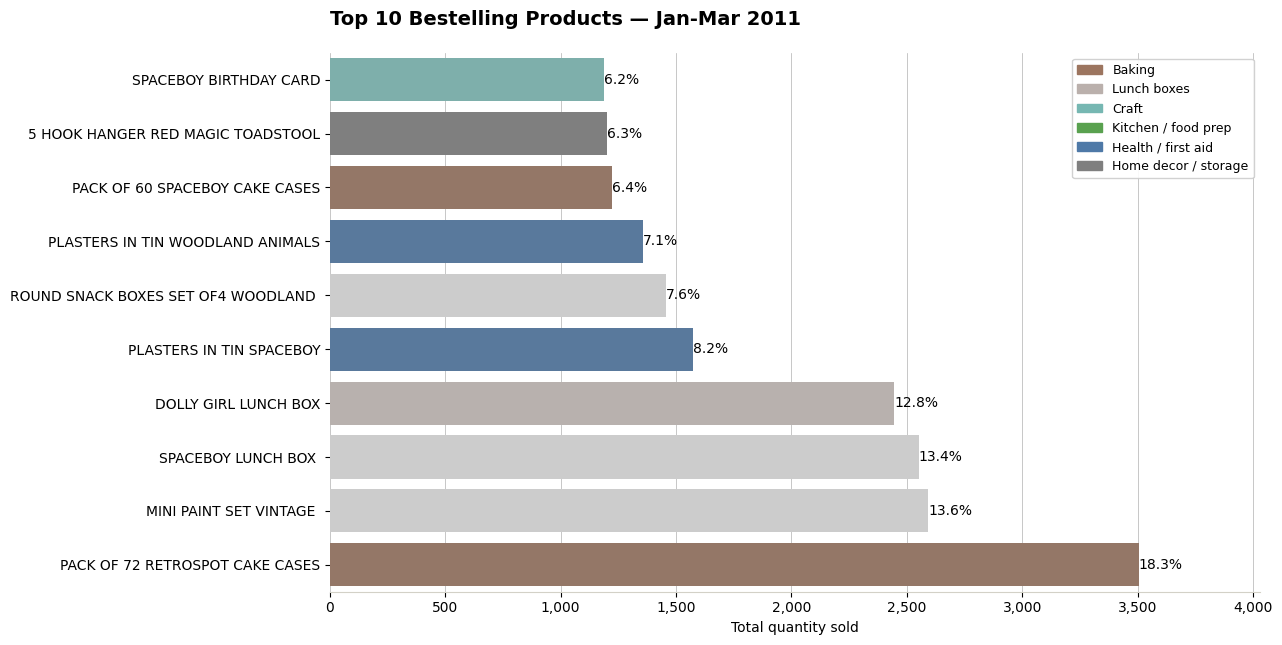

In [101]:
# create new list of top 10 products using the new dataframe filtered by date
top_10_quantity = (
    df_date_filtered.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
    .sort_values("Quantity", ascending=True)
    .reset_index(drop=True)
)

df_date_filtered["Description"] = df_date_filtered["Description"].str.strip()


# create a category map 
category_map = {
    "PACK OF 72 RETROSPOT CAKE CASES": "Baking",
    "SPACEBOY LUNCH BOX": "Lunch boxes",
    "DOLLY GIRL LUNCH BOX": "Lunch boxes",
    "MINI PAINT SET VINTAGE": "Craft",
    "PLASTERS IN TIN SPACEBOY": "Health / first aid",
    "ROUND SNACK BOXES SET OF4 WOODLAND": "Kitchen / food prep",
    "PLASTERS IN TIN WOODLAND ANIMALS": "Health / first aid",
    "5 HOOK HANGER RED MAGIC TOADSTOOL": "Home decor / storage",
    "SPACEBOY BIRTHDAY CARD": "Craft",
    "PACK OF 60 SPACEBOY CAKE CASES": "Baking",
}

category_colors = {
    "Baking": "#9C755F",
    "Lunch boxes": "#BAB0AC",
    "Craft": "#76B7B2",
    "Kitchen / food prep": "#59A14F",
    "Health / first aid": "#4E79A7",
    "Home decor / storage": "#7F7F7F"
}

top_10_quantity["category"] = top_10_quantity["Description"].map(category_map)

top_10_quantity["color"] = top_10_quantity["category"].map(category_colors)
top_10_quantity["color"] = top_10_quantity["color"].fillna("#CCCCCC")

fig, ax = plt.subplots(figsize=(12, 7))

sns.barplot(data=top_10_quantity, x="Quantity", y="Description", palette=top_10_quantity["color"].to_list(), ax=ax)


# add percent labels to the right of each bar
total = top_10_quantity["Quantity"].sum()
top_10_quantity["pct"] = ((top_10_quantity["Quantity"] / total) * 100).round(1)

for i, (qty, pct) in enumerate(zip(top_10_quantity["Quantity"], top_10_quantity["pct"])):
    ax.text(
        qty, 
        i,
        f"{pct}%",
        va="center",
        fontsize=10
    )


# axes
sns.despine(left=True, bottom=False)
ax.xaxis.grid(True, linewidth=0.5, zorder=0)
ax.set_axisbelow(True)
ax.spines["bottom"].set_color("#D3D1C7")
ax.tick_params(axis="x", labelsize=10)
ax.tick_params(axis="y", labelsize=10)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_xlim(0, top_10_quantity["Quantity"].max() * 1.15)

ax.set_title("Top 10 Bestelling Products — Jan-Mar 2011", fontsize=14, fontweight="bold", loc="left", pad=20)

ax.set_xlabel(f"Total quantity sold", fontsize=10)
ax.set_ylabel("")


# add categiry legends
legend_handles = [mpatches.Patch(color=category_colors[cat], label=cat)
for cat in category_colors]

ax.legend(
    handles=legend_handles,
    loc="upper right",
    fontsize=9,
    framealpha=0.9
)

The top seller product, PACK OF 72 RETROSPOT CAKE CASES, contributes 18.3% of units sold among top 10 products. Additionally, Baking category which contains 'PACK OF 72 RETROSPOT CAKE CASES' and 'PACK OF 60 SPACEBOY CAKE CASES' products from top 10 products, have the highest sells. 

The 'SPACEBOY LUNCH BOX' and 'DOLLY GIRL LUNCH BOX' products from Lunch boxes category have a similar sales volume, additionaly both products rank within the top 4 best-selling products. 
 
The top 4 products account for approximately 58% of total sales volume among top-10 products. 

Overall, small number of producst generate the majority of transactions. This indicates for highly concentrated sales distribution.
